In [5]:
import numpy as np
import pandas as pd
import mysql.connector as sql
import requests as r
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pkg_resources'

### Part B: data aquisition

In [53]:
#importing csv file
df=pd.read_csv("D:/data analysis/files/customer_data.csv")
df

,Customer_ID,Age,Gender,Income,Purchases,Churn,Irrelevant_Column
0,1,22.0,Male,25000.0,5.0,No,A
1,2,25.0,Female,30000.0,7.0,Yes,B
2,3,NaN,Female,28000.0,3.0,No,C
3,4,35.0,Male,NaN,8.0,No,D
4,5,40.0,Female,50000.0,10.0,Yes,E
5,6,29.0,Male,32000.0,6.0,No,F
6,7,31.0,Female,35000.0,NaN,Yes,G
7,8,NaN,Male,40000.0,9.0,No,H
8,9,28.0,Female,27000.0,4.0,No,I
9,10,45.0,Male,60000.0,12.0,Yes,J


In [54]:
# importing JSON file
json=pd.read_json("D:/data analysis/files/customer_data.json")
json

,Customer_ID,Age,Gender,Income,Purchases,Churn,Irrelevant_Column
0,1,22.0,Male,25000.0,5.0,No,A
1,2,25.0,Female,30000.0,7.0,Yes,B
2,3,NaN,Female,28000.0,3.0,No,C
3,4,35.0,Male,NaN,8.0,No,D
4,5,40.0,Female,50000.0,10.0,Yes,E
5,6,29.0,Male,32000.0,6.0,No,F
6,7,31.0,Female,35000.0,NaN,Yes,G
7,8,NaN,Male,40000.0,9.0,No,H
8,9,28.0,Female,27000.0,4.0,No,I
9,10,45.0,Male,60000.0,12.0,Yes,J


In [55]:
#importing sql table 
mysql=sql.connect(host='localhost',user='root',password='tamanna@2008',database='data_transformer')
ms=pd.read_sql("select * from customers",mysql)
ms

C:\Users\Admin\AppData\Local\Temp\ipykernel_17320\2258433785.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ms=pd.read_sql("select * from customers",mysql)


,customerID,FirstName,LastName,email,RegistrationDate
0,1,Amit,Sharma,amit.sharma@example.com,2024-05-12
1,2,Priya,Verma,priya.verma@example.com,2024-06-18
2,3,Rahul,Mehta,rahul.mehta@example.com,2024-07-02
3,4,Sneha,Kapoor,sneha.kapoor@example.com,2024-08-25
4,5,Vikas,Rao,vikas.rao@example.com,2024-09-10


In [56]:
# data from api
url = "https://jsonplaceholder.typicode.com/users"
response = r.get(url)
data = response.json()
d = pd.DataFrame(data)
d

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."
5,6,Mrs. Dennis Schulist,Leopoldo_Corkery,Karley_Dach@jasper.info,"{'street': 'Norberto Crossing', 'suite': 'Apt....",1-477-935-8478 x6430,ola.org,"{'name': 'Considine-Lockman', 'catchPhrase': '..."
6,7,Kurtis Weissnat,Elwyn.Skiles,Telly.Hoeger@billy.biz,"{'street': 'Rex Trail', 'suite': 'Suite 280', ...",210.067.6132,elvis.io,"{'name': 'Johns Group', 'catchPhrase': 'Config..."
7,8,Nicholas Runolfsdottir V,Maxime_Nienow,Sherwood@rosamond.me,"{'street': 'Ellsworth Summit', 'suite': 'Suite...",586.493.6943 x140,jacynthe.com,"{'name': 'Abernathy Group', 'catchPhrase': 'Im..."
8,9,Glenna Reichert,Delphine,Chaim_McDermott@dana.io,"{'street': 'Dayna Park', 'suite': 'Suite 449',...",(775)976-6794 x41206,conrad.com,"{'name': 'Yost and Sons', 'catchPhrase': 'Swit..."
9,10,Clementina DuBuque,Moriah.Stanton,Rey.Padberg@karina.biz,"{'street': 'Kattie Turnpike', 'suite': 'Suite ...",024-648-3804,ambrose.net,"{'name': 'Hoeger LLC', 'catchPhrase': 'Central..."


### Part c: data understanding and cleaning

In [57]:
# performing initial exploration
# using head,info and describe to explore
print(df.head(), "\n")
print(df.info(),"\n")
print(df.describe(),"\n")

# finding missing and duplicate values
print(df.isnull(),"\n")
print(df.duplicated())

   Customer_ID   Age  Gender   Income  Purchases Churn Irrelevant_Column
0            1  22.0    Male  25000.0        5.0    No                 A
1            2  25.0  Female  30000.0        7.0   Yes                 B
2            3   NaN  Female  28000.0        3.0    No                 C
3            4  35.0    Male      NaN        8.0    No                 D
4            5  40.0  Female  50000.0       10.0   Yes                 E 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        11 non-null     int64  
 1   Age                9 non-null      float64
 2   Gender             11 non-null     object 
 3   Income             10 non-null     float64
 4   Purchases          10 non-null     float64
 5   Churn              11 non-null     object 
 6   Irrelevant_Column  11 non-null     object 
dtypes: float64(3), int64(

In [58]:
# applying data cleaning
# handle missing data 
df = df.fillna(df.mean(numeric_only=True))

# correct inconsistent datatypes
df['Age'] = df['Age'].astype(int)

# drop irrelevent columns 
df = df.drop(columns=['Irrelevant_Column'])
df

,Customer_ID,Age,Gender,Income,Purchases,Churn
0,1,22,Male,25000.0,5.0,No
1,2,25,Female,30000.0,7.0,Yes
2,3,33,Female,28000.0,3.0,No
3,4,35,Male,38700.0,8.0,No
4,5,40,Female,50000.0,10.0,Yes
5,6,29,Male,32000.0,6.0,No
6,7,31,Female,35000.0,7.6,Yes
7,8,33,Male,40000.0,9.0,No
8,9,28,Female,27000.0,4.0,No
9,10,45,Male,60000.0,12.0,Yes


### Part D: EDA

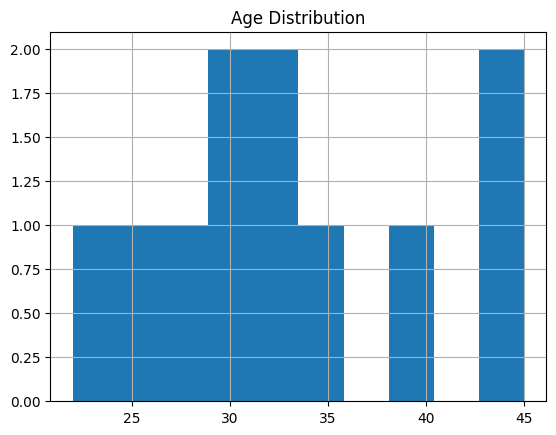

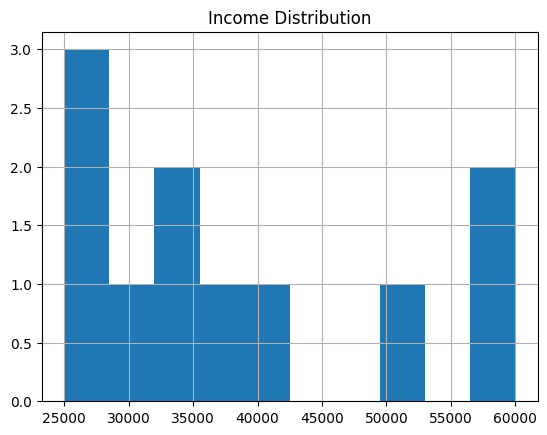

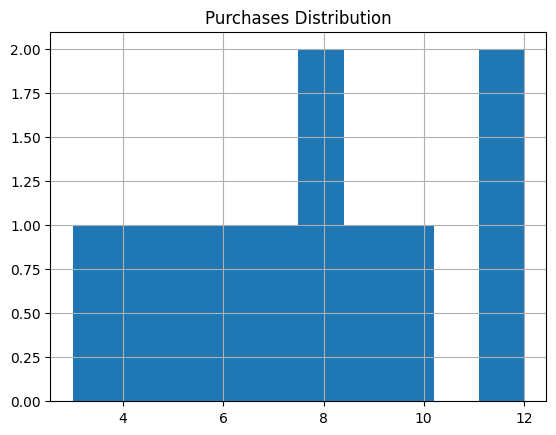

In [60]:
# univariate analysis
# age 
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

# income 
df['Income'].hist()
plt.title("Income Distribution")
plt.show()

# purchases
df['Purchases'].hist()
plt.title("Purchases Distribution")
plt.show()

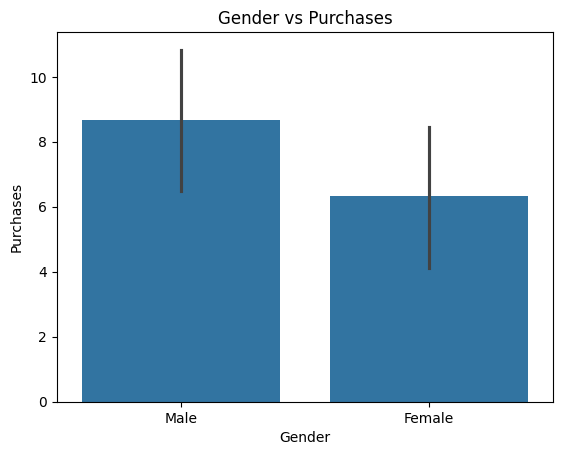

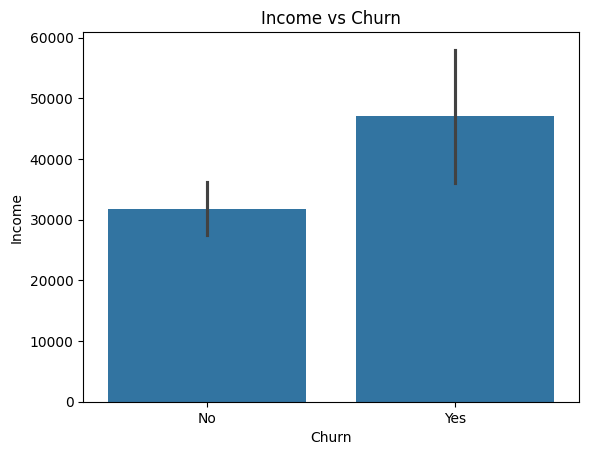

In [63]:
# Bivariate analysis
# Gender vs Purchases
sns.barplot(x='Gender', y='Purchases', data=df)
plt.title("Gender vs Purchases")
plt.show()

# Income vs Churn
sns.barplot(x='Churn', y='Income', data=df)
plt.title("Income vs Churn")
plt.show()

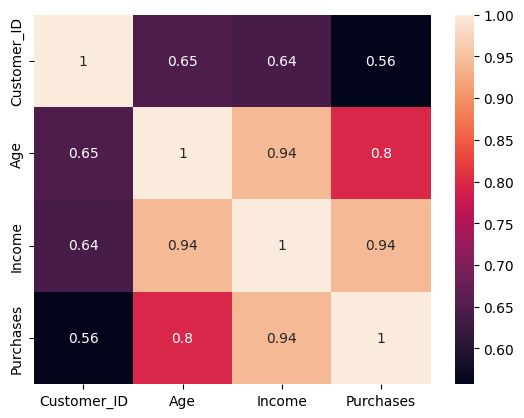

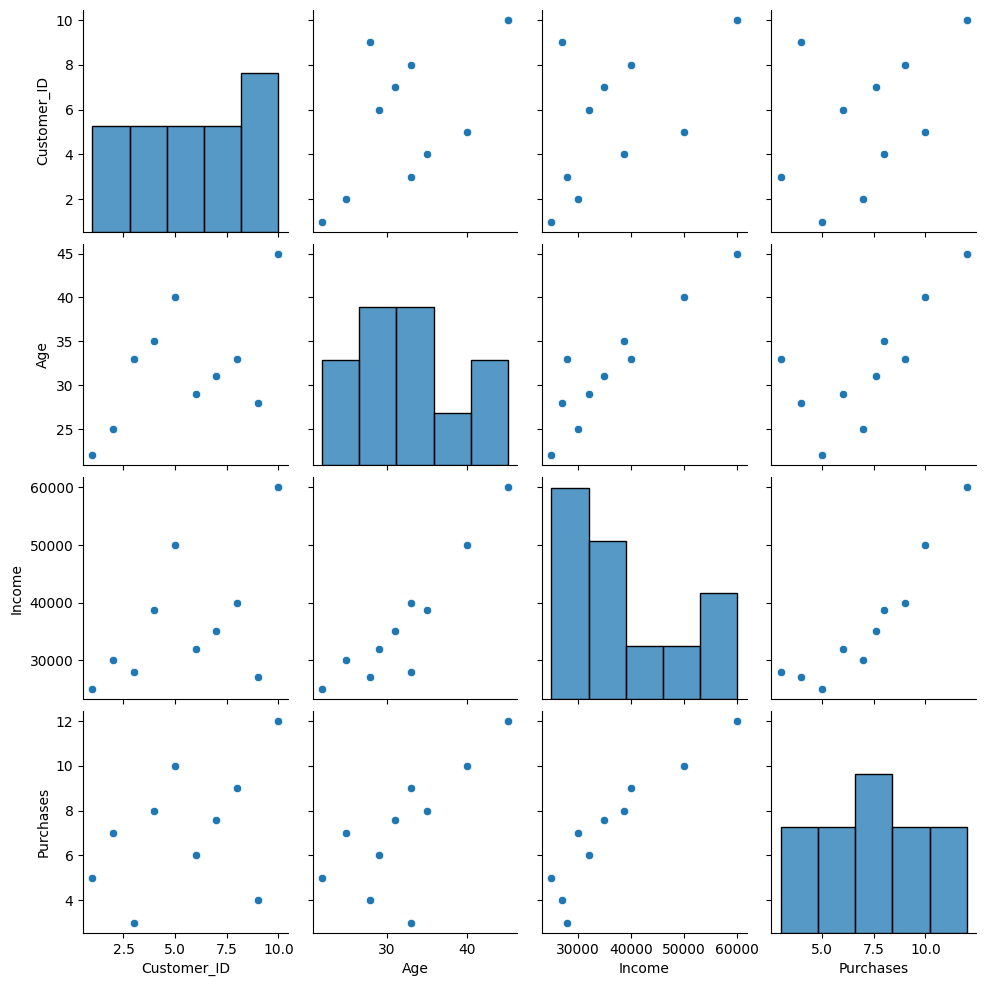

In [64]:
# multivariate analysis
# correlation heatmap of all numerical values
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# pair plots to identify feature interaction
sns.pairplot(df)
plt.show()

### Part E : Pandas profiling

In [4]:
profile = ProfileReport(df, explorative=True)
profile.to_file("report.html")


NameError: name 'ProfileReport' is not defined